Log Data Shape: (2000, 9)
Label Data Shape: (575061, 2)
Merged Dataset Shape: (2000, 11)
Anomaly Distribution:
 Label
0    1931
1      69
Name: count, dtype: int64
Training samples: 1600
Testing samples: 400

===== EVALUATION RESULTS =====
Accuracy: 0.935
ROC-AUC: 0.4844559585492228

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.97      0.97       386
           1       0.00      0.00      0.00        14

    accuracy                           0.94       400
   macro avg       0.48      0.48      0.48       400
weighted avg       0.93      0.94      0.93       400

Confusion Matrix:

[[374  12]
 [ 14   0]]


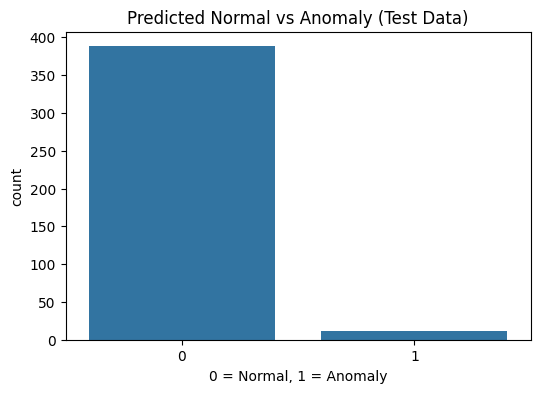


Pipeline Completed Successfully.


In [ ]:
# ============================================================
# AI Driven Log Anomaly Detection
# Isolation Forest (2k)
# ============================================================

# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------

print("Log Data Shape:", log_df.shape)
print("Label Data Shape:", label_df.shape)

# ------------------------------------------------------------
# EXTRACT BLOCK ID FROM CONTENT
# ------------------------------------------------------------

def extract_block_id(text):
    match = re.search(r'(blk_-?\d+)', str(text))
    if match:
        return match.group(1)
    return None

log_df['BlockId'] = log_df['Content'].apply(extract_block_id)

# ------------------------------------------------------------
# MERGE WITH LABEL FILE
# ------------------------------------------------------------

merged_df = pd.merge(log_df, label_df, on='BlockId', how='left')

# Replace missing labels as Normal (safe assumption)
merged_df['Label'] = merged_df['Label'].fillna('Normal')

# Convert to binary
merged_df['Label'] = merged_df['Label'].map({'Normal':0, 'Anomaly':1})

print("Merged Dataset Shape:", merged_df.shape)
print("Anomaly Distribution:\n", merged_df['Label'].value_counts())

# ------------------------------------------------------------
# FEATURE ENGINEERING
# ------------------------------------------------------------

merged_df = merged_df.dropna().reset_index(drop=True)

# Number count
merged_df['num_count'] = merged_df['Content'].apply(lambda x: len(re.findall(r'\d+', str(x))))

# Message length
merged_df['msg_length'] = merged_df['Content'].apply(lambda x: len(str(x)))

# Block frequency
merged_df['block_id_freq'] = merged_df.groupby('BlockId')['BlockId'].transform('count')

# ------------------------------------------------------------
# ENCODE CATEGORICAL COLUMNS
# ------------------------------------------------------------

categorical_cols = merged_df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    if col not in ['Label', 'BlockId']:
        le = LabelEncoder()
        merged_df[col] = le.fit_transform(merged_df[col])

# ------------------------------------------------------------
# PREPARE FEATURES & LABELS
# ------------------------------------------------------------

y = merged_df['Label']
X = merged_df.drop(columns=['Label', 'BlockId'])

X = X.select_dtypes(include=[np.number])

# ------------------------------------------------------------
# SCALE FEATURES
# ------------------------------------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ------------------------------------------------------------
# TRAIN-TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

# ------------------------------------------------------------
# TRAIN ISOLATION FOREST 
# ------------------------------------------------------------

model = IsolationForest(
    n_estimators=200,
    contamination=y_train.mean(),  # use actual anomaly ratio
    random_state=42
)

model.fit(X_train)

# ------------------------------------------------------------
# PREDICT ON TEST
# ------------------------------------------------------------

y_pred = model.predict(X_test)

# Convert (-1 anomaly, 1 normal) → (1 anomaly, 0 normal)
y_pred = np.where(y_pred == -1, 1, 0)

# ------------------------------------------------------------
# EVALUATION
# ------------------------------------------------------------

print("\n===== EVALUATION RESULTS =====")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

# ------------------------------------------------------------
# VISUALIZATION
# ------------------------------------------------------------

plt.figure(figsize=(6,4))
sns.countplot(x=y_pred)
plt.title("Predicted Normal vs Anomaly (Test Data)")
plt.xlabel("0 = Normal, 1 = Anomaly")
plt.show()

print("\nPipeline Completed Successfully.")

Anomaly Distribution:
 Label
0    1931
1      69
Name: count, dtype: int64
Train size: (1600, 93)
Test size: (400, 93)

===== IMPROVED MODEL RESULTS =====
Accuracy: 0.9175
ROC-AUC: 0.5098075499629904

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.95      0.96       386
           1       0.05      0.07      0.06        14

    accuracy                           0.92       400
   macro avg       0.51      0.51      0.51       400
weighted avg       0.93      0.92      0.93       400

Confusion Matrix:

[[366  20]
 [ 13   1]]


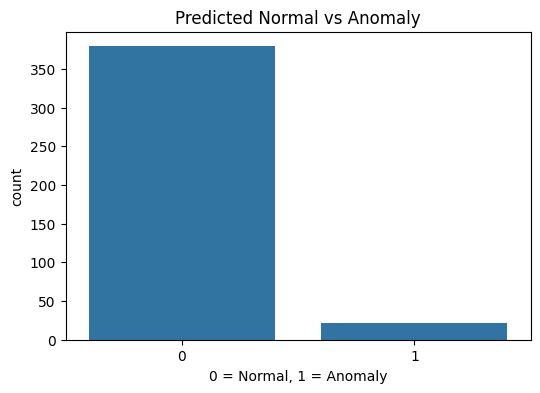


Improved Pipeline Completed Successfully.


In [ ]:
# ============================================================
# AI Driven Log Anomaly Detection 
# TF-IDF + Normal-Only Training + Isolation Forest (2k)
# ============================================================

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from sklearn.feature_extraction.text import TfidfVectorizer

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------

# ------------------------------------------------------------
# EXTRACT BLOCK ID
# ------------------------------------------------------------

def extract_block_id(text):
    match = re.search(r'(blk_-?\d+)', str(text))
    if match:
        return match.group(1)
    return None

log_df['BlockId'] = log_df['Content'].apply(extract_block_id)

# ------------------------------------------------------------
# MERGE LABELS
# ------------------------------------------------------------

merged_df = pd.merge(log_df, label_df, on='BlockId', how='left')
merged_df['Label'] = merged_df['Label'].fillna('Normal')
merged_df['Label'] = merged_df['Label'].map({'Normal':0, 'Anomaly':1})

print("Anomaly Distribution:\n", merged_df['Label'].value_counts())

# ------------------------------------------------------------
# FEATURE ENGINEERING 
# ------------------------------------------------------------

merged_df['num_count'] = merged_df['Content'].apply(lambda x: len(re.findall(r'\d+', str(x))))
merged_df['msg_length'] = merged_df['Content'].apply(lambda x: len(str(x)))
merged_df['block_id_freq'] = merged_df.groupby('BlockId')['BlockId'].transform('count')
merged_df['event_freq'] = merged_df.groupby('EventId')['EventId'].transform('count')

numeric_features = ['num_count','msg_length','block_id_freq','event_freq']
X_numeric = merged_df[numeric_features].values

# ------------------------------------------------------------
# TF-IDF ON EVENT TEMPLATE 
# ------------------------------------------------------------

tfidf = TfidfVectorizer(
    max_features=300,
    ngram_range=(1,2)
)

X_text = tfidf.fit_transform(merged_df['EventTemplate']).toarray()

# ------------------------------------------------------------
# COMBINE FEATURES
# ------------------------------------------------------------

X_combined = np.hstack((X_numeric, X_text))
y = merged_df['Label'].values

# ------------------------------------------------------------
# SCALE FEATURES
# ------------------------------------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined)

# ------------------------------------------------------------
# TRAIN-TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

# ------------------------------------------------------------
# TRAIN ONLY ON NORMAL DATA
# ------------------------------------------------------------

X_train_normal = X_train[y_train == 0]

model = IsolationForest(
    n_estimators=300,
    contamination=0.05,   # can tune between 0.03–0.1
    random_state=42
)

model.fit(X_train_normal)

# ------------------------------------------------------------
# PREDICT
# ------------------------------------------------------------

y_pred = model.predict(X_test)
y_pred = np.where(y_pred == -1, 1, 0)

# ------------------------------------------------------------
# EVALUATION
# ------------------------------------------------------------

print("\n===== IMPROVED MODEL RESULTS =====")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

# ------------------------------------------------------------
# VISUALIZATION
# ------------------------------------------------------------

plt.figure(figsize=(6,4))
sns.countplot(x=y_pred)
plt.title("Predicted Normal vs Anomaly")
plt.xlabel("0 = Normal, 1 = Anomaly")
plt.show()

print("\nImproved Pipeline Completed Successfully.")

In [ ]:
# ============================================================
#  AI Driven Log Anomaly Detection
# Random Forest Model (2k)
# ============================================================

import pandas as pd
import numpy as np
import re
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from scipy.stats import entropy

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------

# ------------------------------------------------------------
# EXTRACT BLOCK ID
# ------------------------------------------------------------

def extract_block_id(text):
    match = re.search(r'(blk_-?\d+)', str(text))
    if match:
        return match.group(1)
    return None

log_df['BlockId'] = log_df['Content'].apply(extract_block_id)

# Merge labels
merged_df = pd.merge(log_df, label_df, on='BlockId', how='left')
merged_df['Label'] = merged_df['Label'].fillna('Normal')
merged_df['Label'] = merged_df['Label'].map({'Normal':0, 'Anomaly':1})

# ------------------------------------------------------------
# BLOCK-LEVEL FEATURE ENGINEERING
# ------------------------------------------------------------

block_features = []

for block_id, group in merged_df.groupby('BlockId'):
    
    label = group['Label'].iloc[0]
    
    num_logs = len(group)
    unique_events = group['EventId'].nunique()
    
    # Event frequency distribution
    event_counts = group['EventId'].value_counts().values
    event_entropy = entropy(event_counts)
    
    # Most frequent event encoded
    most_freq_event = group['EventId'].value_counts().idxmax()
    
    # Numeric patterns
    msg_lengths = group['Content'].apply(lambda x: len(str(x)))
    avg_msg_length = msg_lengths.mean()
    
    num_count = group['Content'].apply(lambda x: len(re.findall(r'\d+', str(x)))).mean()
    
    block_features.append([
        block_id,
        num_logs,
        unique_events,
        event_entropy,
        most_freq_event,
        avg_msg_length,
        num_count,
        label
    ])

block_df = pd.DataFrame(block_features, columns=[
    'BlockId','num_logs','unique_events','event_entropy',
    'most_freq_event','avg_msg_length','num_count','Label'
])

# Encode most frequent event
le = LabelEncoder()
block_df['most_freq_event'] = le.fit_transform(block_df['most_freq_event'])

# ------------------------------------------------------------
# TRAIN-TEST SPLIT
# ------------------------------------------------------------

X = block_df.drop(columns=['BlockId','Label'])
y = block_df['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ------------------------------------------------------------
# RANDOM FOREST MODEL
# ------------------------------------------------------------

model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

# ------------------------------------------------------------
# EVALUATION
# ------------------------------------------------------------

y_pred = model.predict(X_test)

print("\n===== BLOCK-LEVEL RANDOM FOREST RESULTS =====\n")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

try:
    print("ROC-AUC:", roc_auc_score(y_test, y_pred))
except:
    print("ROC-AUC could not be calculated.")


===== BLOCK-LEVEL RANDOM FOREST RESULTS =====

              precision    recall  f1-score   support

           0       0.96      0.75      0.84       385
           1       0.02      0.14      0.04        14

    accuracy                           0.73       399
   macro avg       0.49      0.45      0.44       399
weighted avg       0.93      0.73      0.82       399

Confusion Matrix:
 [[290  95]
 [ 12   2]]
ROC-AUC: 0.44805194805194803


In [ ]:
# ============================================================
#  AI Driven Log Anomaly Detection
# SMOTE + XGBoost (2k)
# ============================================================

import pandas as pd
import numpy as np
import re
from collections import Counter
from scipy.stats import entropy
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------

# ------------------------------------------------------------
# EXTRACT BLOCK ID
# ------------------------------------------------------------

def extract_block_id(text):
    match = re.search(r'(blk_-?\d+)', str(text))
    if match:
        return match.group(1)
    return None

log_df['BlockId'] = log_df['Content'].apply(extract_block_id)

merged_df = pd.merge(log_df, label_df, on='BlockId', how='left')
merged_df['Label'] = merged_df['Label'].fillna('Normal')
merged_df['Label'] = merged_df['Label'].map({'Normal':0, 'Anomaly':1})

# ------------------------------------------------------------
# ADVANCED BLOCK FEATURES
# ------------------------------------------------------------

block_features = []

for block_id, group in merged_df.groupby('BlockId'):
    
    label = group['Label'].iloc[0]
    
    num_logs = len(group)
    unique_events = group['EventId'].nunique()
    
    event_counts = group['EventId'].value_counts().values
    event_entropy = entropy(event_counts)
    
    event_variety_ratio = unique_events / num_logs
    
    avg_msg_length = group['Content'].apply(lambda x: len(str(x))).mean()
    digit_density = group['Content'].apply(lambda x: len(re.findall(r'\d', str(x)))).mean()
    
    block_features.append([
        num_logs,
        unique_events,
        event_entropy,
        event_variety_ratio,
        avg_msg_length,
        digit_density,
        label
    ])

block_df = pd.DataFrame(block_features, columns=[
    'num_logs','unique_events','event_entropy',
    'event_variety_ratio','avg_msg_length','digit_density','Label'
])

# ------------------------------------------------------------
# TRAIN TEST SPLIT
# ------------------------------------------------------------

X = block_df.drop(columns=['Label'])
y = block_df['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ------------------------------------------------------------
# SCALE + SMOTE
# ------------------------------------------------------------

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print("After SMOTE distribution:", np.bincount(y_train_bal))

# ------------------------------------------------------------
# XGBOOST MODEL
# ------------------------------------------------------------

model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=1,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train_bal, y_train_bal)

# ------------------------------------------------------------
# EVALUATION
# ------------------------------------------------------------

y_pred = model.predict(X_test_scaled)

print("\n===== SMOTE + XGBOOST RESULTS =====\n")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

After SMOTE distribution: [1541 1541]

===== SMOTE + XGBOOST RESULTS =====

              precision    recall  f1-score   support

           0       0.96      0.94      0.95       385
           1       0.00      0.00      0.00        14

    accuracy                           0.91       399
   macro avg       0.48      0.47      0.48       399
weighted avg       0.93      0.91      0.92       399

Confusion Matrix:
 [[363  22]
 [ 14   0]]
ROC-AUC: 0.4714285714285714


In [ ]:
# ============================================================
#  AI Driven Log Anomaly Detection
# EventId Frequency Vector + XGBoost (2k)
# ============================================================

import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from xgboost import XGBClassifier

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------

# ------------------------------------------------------------
# EXTRACT BLOCK ID
# ------------------------------------------------------------

def extract_block_id(text):
    match = re.search(r'(blk_-?\d+)', str(text))
    return match.group(1) if match else None

log_df['BlockId'] = log_df['Content'].apply(extract_block_id)

merged_df = pd.merge(log_df, label_df, on='BlockId', how='left')
merged_df['Label'] = merged_df['Label'].fillna('Normal')
merged_df['Label'] = merged_df['Label'].map({'Normal':0, 'Anomaly':1})

# ------------------------------------------------------------
# EVENTID FREQUENCY VECTOR PER BLOCK
# ------------------------------------------------------------

# Pivot table: BlockId x EventId
block_event_matrix = pd.crosstab(
    merged_df['BlockId'],
    merged_df['EventId']
)

# Add labels
block_event_matrix['Label'] = merged_df.groupby('BlockId')['Label'].first()

# ------------------------------------------------------------
# TRAIN TEST SPLIT
# ------------------------------------------------------------

X = block_event_matrix.drop(columns=['Label'])
y = block_event_matrix['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Compute class weight ratio
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

# ------------------------------------------------------------
# XGBOOST MODEL
# ------------------------------------------------------------

model = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train)

# ------------------------------------------------------------
# EVALUATION
# ------------------------------------------------------------

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("\n===== EVENT FREQUENCY + XGBOOST RESULTS =====\n")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


===== EVENT FREQUENCY + XGBOOST RESULTS =====

              precision    recall  f1-score   support

           0       0.96      0.70      0.81       385
           1       0.03      0.21      0.04        14

    accuracy                           0.68       399
   macro avg       0.49      0.46      0.43       399
weighted avg       0.93      0.68      0.78       399

Confusion Matrix:
 [[268 117]
 [ 11   3]]
ROC-AUC: 0.48617810760667907


In [ ]:
# ============================================================
# AI Driven Log Anomaly Detection
# DeepLog 
# ============================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.utils import to_categorical
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)

# ------------------------------------------------------------
# LOAD EVENT_TRACES
# ------------------------------------------------------------

print("Columns:", trace_df.columns)
print("Total blocks:", len(trace_df))

# ------------------------------------------------------------
# CORRECT LABEL MAPPING
# ------------------------------------------------------------

print("Unique labels before mapping:", trace_df['Label'].unique())

trace_df['Label'] = trace_df['Label'].map({
    'Success': 0,
    'Fail': 1
})

print("Label distribution after mapping:")
print(trace_df['Label'].value_counts())

# ------------------------------------------------------------
# CONVERT FEATURES TO SEQUENCE
# ------------------------------------------------------------

trace_df['Features'] = trace_df['Features'].apply(
    lambda x: x.strip('[]').replace(" ", "").split(',')
)

# Build vocabulary
all_events = set(e for seq in trace_df['Features'] for e in seq)
event_to_idx = {event:i+1 for i,event in enumerate(sorted(all_events))}
vocab_size = len(event_to_idx) + 1

print("Vocabulary size:", vocab_size)

# Convert to integer sequences
trace_df['Features'] = trace_df['Features'].apply(
    lambda seq: [event_to_idx[e] for e in seq]
)

# ------------------------------------------------------------
# TRAIN ON NORMAL ONLY
# ------------------------------------------------------------

normal_df = trace_df[trace_df['Label'] == 0]
anomaly_df = trace_df[trace_df['Label'] == 1]

train_df, val_df = train_test_split(
    normal_df,
    test_size=0.1,
    random_state=42
)

test_df = pd.concat([val_df, anomaly_df])

print("Train blocks:", len(train_df))
print("Test blocks:", len(test_df))

# ------------------------------------------------------------
# SLIDING WINDOW
# ------------------------------------------------------------

window_size = 10

def generate_sequences(df):
    X, y, block_ids = [], [], []
    
    for _, row in df.iterrows():
        seq = row['Features']
        block_id = row['BlockId']
        
        if len(seq) <= window_size:
            continue
        
        for i in range(len(seq) - window_size):
            X.append(seq[i:i+window_size])
            y.append(seq[i+window_size])
            block_ids.append(block_id)
    
    return np.array(X), np.array(y), np.array(block_ids)

X_train, y_train, _ = generate_sequences(train_df)
X_test, y_test, test_block_ids = generate_sequences(test_df)

print("Train samples:", X_train.shape)
print("Test samples:", X_test.shape)

# ------------------------------------------------------------
# BUILD OPTIMIZED MODEL
# ------------------------------------------------------------

from tensorflow.keras.losses import SparseCategoricalCrossentropy

model = Sequential([
    Embedding(vocab_size, 64),
    LSTM(64),
    Dense(vocab_size, activation='softmax')
])

model.compile(
    loss=SparseCategoricalCrossentropy(),
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

# ------------------------------------------------------------
# TRAIN 
# ------------------------------------------------------------

model.fit(
    X_train,
    y_train,  
    epochs=2,  
    batch_size=2048,
    validation_split=0.1
)

# ------------------------------------------------------------
# TOP-K ANOMALY DETECTION
# ------------------------------------------------------------

top_k = 9
y_prob = model.predict(X_test, verbose=0)

window_anomaly = []

for i in range(len(X_test)):
    top_preds = np.argsort(y_prob[i])[-top_k:]
    if y_test[i] not in top_preds:
        window_anomaly.append(1)
    else:
        window_anomaly.append(0)

window_anomaly = np.array(window_anomaly)

# ------------------------------------------------------------
# BLOCK LEVEL EVALUATION
# ------------------------------------------------------------

block_pred = {}

for block_id, flag in zip(test_block_ids, window_anomaly):
    if block_id not in block_pred:
        block_pred[block_id] = 0
    if flag == 1:
        block_pred[block_id] = 1

true_labels = test_df.set_index('BlockId')['Label'].to_dict()

y_true = []
y_pred = []

for block_id in block_pred:
    y_true.append(true_labels[block_id])
    y_pred.append(block_pred[block_id])

print("\n===== BLOCK LEVEL RESULTS =====\n")
print(classification_report(y_true, y_pred))
print("ROC-AUC:", roc_auc_score(y_true, y_pred))

TensorFlow Version: 2.19.0
Columns: Index(['BlockId', 'Label', 'Type', 'Features', 'TimeInterval', 'Latency'], dtype='object')
Total blocks: 575061
Unique labels before mapping: ['Success' 'Fail']
Label distribution after mapping:
Label
0    558223
1     16838
Name: count, dtype: int64
Vocabulary size: 30
Train blocks: 502400
Test blocks: 72661
Train samples: (4773687, 10)
Test samples: (694344, 10)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/2
2098/2098 ━━━━━━━━━━━━━━━━━━━━ 175s 82ms/step - accuracy: 0.8699 - loss: 0.4261 - val_accuracy: 0.9213 - val_loss: 0.1981
Epoch 2/2
2098/2098 ━━━━━━━━━━━━━━━━━━━━ 172s 82ms/step - accuracy: 0.9214 - loss: 0.1967 - val_accuracy: 0.9221 - val_loss: 0.1924

===== BLOCK LEVEL RESULTS =====

              precision    recall  f1-score   support

           0       0.88      1.00      0.94     55823
           1       0.99      0.30      0.46     10647

    accuracy                           0.89     66470
   macro avg       0.94      0.65      0.70     66470
weighted avg       0.90      0.89      0.86     66470

ROC-AUC: 0.6493935119412073



Running inference with Top-3...

340/340 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step
Total window anomalies detected: 22304

===== BLOCK LEVEL CLASSIFICATION REPORT =====

              precision    recall  f1-score   support

           0       0.94      0.91      0.93     55823
           1       0.60      0.71      0.65     10647

    accuracy                           0.88     66470
   macro avg       0.77      0.81      0.79     66470
weighted avg       0.89      0.88      0.88     66470

ROC-AUC: 0.8115893983237056

Confusion Matrix:
[[50842  4981]
 [ 3062  7585]]


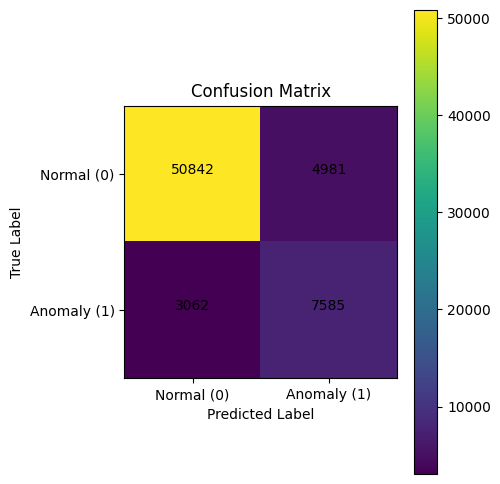

In [21]:
# ============================================================
# TOP-K WINDOW ANOMALY DETECTION
# ============================================================

import numpy as np
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt

top_k = 3   # <-- You can tune this (1,3,5,7,9)

print(f"\nRunning inference with Top-{top_k}...\n")

y_prob = model.predict(X_test, batch_size=2048, verbose=1)

window_anomaly = []

for i in range(len(X_test)):
    top_preds = np.argsort(y_prob[i])[-top_k:]
    if y_test[i] not in top_preds:
        window_anomaly.append(1)
    else:
        window_anomaly.append(0)

window_anomaly = np.array(window_anomaly)

print("Total window anomalies detected:", window_anomaly.sum())

# ============================================================
# BLOCK LEVEL AGGREGATION
# ============================================================

block_pred = {}

for block_id, flag in zip(test_block_ids, window_anomaly):
    if block_id not in block_pred:
        block_pred[block_id] = 0
    if flag == 1:
        block_pred[block_id] = 1

true_labels = test_df.set_index('BlockId')['Label'].to_dict()

y_true = []
y_pred = []

for block_id in block_pred:
    y_true.append(true_labels[block_id])
    y_pred.append(block_pred[block_id])

# ============================================================
# RESULTS
# ============================================================

print("\n===== BLOCK LEVEL CLASSIFICATION REPORT =====\n")
print(classification_report(y_true, y_pred))

roc = roc_auc_score(y_true, y_pred)
print("ROC-AUC:", roc)

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_true, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(5,5))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()

classes = ["Normal (0)", "Anomaly (1)"]
tick_marks = np.arange(len(classes))

plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center")

plt.tight_layout()
plt.show()

TensorFlow Version: 2.19.0
Vocabulary size: 30
Train blocks: 502400
Test blocks: 72661
Train samples: (657783, 20)
Test samples: (130894, 20)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/7
290/290 ━━━━━━━━━━━━━━━━━━━━ 316s 1s/step - accuracy: 0.7993 - loss: 0.6184 - val_accuracy: 0.9391 - val_loss: 0.1665
Epoch 2/7
290/290 ━━━━━━━━━━━━━━━━━━━━ 324s 1s/step - accuracy: 0.9373 - loss: 0.1649 - val_accuracy: 0.9457 - val_loss: 0.1327
Epoch 3/7
290/290 ━━━━━━━━━━━━━━━━━━━━ 300s 1s/step - accuracy: 0.9436 - loss: 0.1341 - val_accuracy: 0.9467 - val_loss: 0.1194
Epoch 4/7
290/290 ━━━━━━━━━━━━━━━━━━━━ 297s 1s/step - accuracy: 0.9462 - loss: 0.1232 - val_accuracy: 0.9486 - val_loss: 0.1129
Epoch 5/7
290/290 ━━━━━━━━━━━━━━━━━━━━ 315s 1s/step - accuracy: 0.9466 - loss: 0.1190 - val_accuracy: 0.9486 - val_loss: 0.1102
Epoch 6/7
290/290 ━━━━━━━━━━━━━━━━━━━━ 308s 1s/step - accuracy: 0.9473 - loss: 0.1153 - val_accuracy: 0.9493 - val_loss: 0.1096
Epoch 7/7
290/290 ━━━━━━━━━━━━━━━━━━━━ 297s 1s/step - accuracy: 0.9482 - loss: 0.1129 - val_accuracy: 0.9500 - val_loss: 0.1080

Running Top-3 Detection...

64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 305ms/step

===== BLOCK LEVEL CLASSIFICATION

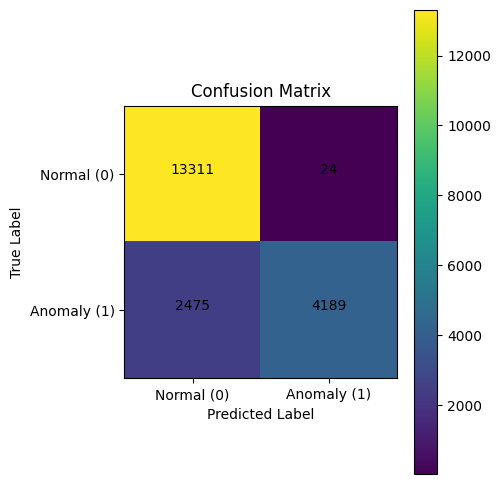

In [ ]:
# ============================================================
# AI Driven Log Anomaly Detection
# DeepLog (Optimized Version)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.losses import SparseCategoricalCrossentropy

print("TensorFlow Version:", tf.__version__)

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------

# ------------------------------------------------------------
# LABEL MAPPING
# ------------------------------------------------------------

trace_df['Label'] = trace_df['Label'].map({'Success': 0, 'Fail': 1})

# ------------------------------------------------------------
# CONVERT FEATURES TO SEQUENCES
# ------------------------------------------------------------

trace_df['Features'] = trace_df['Features'].apply(
    lambda x: x.strip('[]').replace(" ", "").split(',')
)

all_events = set(e for seq in trace_df['Features'] for e in seq)
event_to_idx = {event:i+1 for i,event in enumerate(sorted(all_events))}
vocab_size = len(event_to_idx) + 1

trace_df['Features'] = trace_df['Features'].apply(
    lambda seq: [event_to_idx[e] for e in seq]
)

print("Vocabulary size:", vocab_size)

# ------------------------------------------------------------
# TRAIN ONLY ON NORMAL LOGS
# ------------------------------------------------------------

normal_df = trace_df[trace_df['Label'] == 0]
anomaly_df = trace_df[trace_df['Label'] == 1]

train_df, val_df = train_test_split(
    normal_df,
    test_size=0.1,
    random_state=42
)

test_df = pd.concat([val_df, anomaly_df])

print("Train blocks:", len(train_df))
print("Test blocks:", len(test_df))

# ------------------------------------------------------------
# SLIDING WINDOW (Window Size Increased)
# ------------------------------------------------------------

window_size = 20

def generate_sequences(df):
    X, y, block_ids = [], [], []
    
    for _, row in df.iterrows():
        seq = row['Features']
        block_id = row['BlockId']
        
        if len(seq) <= window_size:
            continue
        
        for i in range(len(seq) - window_size):
            X.append(seq[i:i+window_size])
            y.append(seq[i+window_size])
            block_ids.append(block_id)
    
    return np.array(X), np.array(y), np.array(block_ids)

X_train, y_train, _ = generate_sequences(train_df)
X_test, y_test, test_block_ids = generate_sequences(test_df)

print("Train samples:", X_train.shape)
print("Test samples:", X_test.shape)

# ------------------------------------------------------------
# BUILD IMPROVED MODEL
# ------------------------------------------------------------

model = Sequential([
    Embedding(vocab_size, 128),
    LSTM(256, dropout=0.2, recurrent_dropout=0.2),
    Dense(vocab_size, activation='softmax')
])

model.compile(
    loss=SparseCategoricalCrossentropy(),
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

# ------------------------------------------------------------
# TRAIN LONGER
# ------------------------------------------------------------

model.fit(
    X_train,
    y_train,
    epochs=7,
    batch_size=2048,
    validation_split=0.1
)

# ------------------------------------------------------------
# TOP-K ANOMALY DETECTION
# ------------------------------------------------------------

top_k = 3   # Tune between 1–5

print(f"\nRunning Top-{top_k} Detection...\n")

y_prob = model.predict(X_test, batch_size=2048, verbose=1)

window_anomaly = []

for i in range(len(X_test)):
    top_preds = np.argsort(y_prob[i])[-top_k:]
    if y_test[i] not in top_preds:
        window_anomaly.append(1)
    else:
        window_anomaly.append(0)

window_anomaly = np.array(window_anomaly)

# ------------------------------------------------------------
# BLOCK LEVEL AGGREGATION
# ------------------------------------------------------------

block_pred = {}

for block_id, flag in zip(test_block_ids, window_anomaly):
    if block_id not in block_pred:
        block_pred[block_id] = 0
    if flag == 1:
        block_pred[block_id] = 1

true_labels = test_df.set_index('BlockId')['Label'].to_dict()

y_true = []
y_pred = []

for block_id in block_pred:
    y_true.append(true_labels[block_id])
    y_pred.append(block_pred[block_id])

# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

print("\n===== BLOCK LEVEL CLASSIFICATION REPORT =====\n")
print(classification_report(y_true, y_pred))

roc = roc_auc_score(y_true, y_pred)
print("ROC-AUC:", roc)

# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(y_true, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(5,5))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()

classes = ["Normal (0)", "Anomaly (1)"]
tick_marks = np.arange(len(classes))

plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center")

plt.tight_layout()
plt.show()

2026-03-31 19:30:39.802846: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774985440.153412      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774985440.276417      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774985440.954775      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774985440.954846      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774985440.954851      55 computation_placer.cc:177] computation placer alr

TensorFlow Version: 2.19.0
Vocabulary size: 30
Train blocks: 502400
Test blocks: 72661
Train samples: (46106, 30)
Validation samples: (6003, 30)
Test samples: (18673, 30)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2026-03-31 19:31:54.379508: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 30, 128)   │      3,840 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 30, 256)   │    263,168 │ embedding[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 30, 256)   │          0 │ bidirectional[0]… │
│ (Attention)         │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ attention[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 30)        │      7,710 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 274,718 (1.05 MB)

 Trainable params: 274,718 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.5744 - loss: 1.7970 - val_accuracy: 0.8692 - val_loss: 0.5559
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.8885 - loss: 0.4677 - val_accuracy: 0.9067 - val_loss: 0.3599
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.9055 - loss: 0.3232 - val_accuracy: 0.9074 - val_loss: 0.2888
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.9100 - loss: 0.2707 - val_accuracy: 0.9155 - val_loss: 0.2631
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.9157 - loss: 0.2471 - val_accuracy: 0.9214 - val_loss: 0.2407
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.9237 - loss: 0.2221 - val_accuracy: 0.9324 - val_loss: 0.2379
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.9327 - loss: 0.2136 - val_accuracy: 0.9400 - val_loss: 0.2129
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.9410 - loss: 0.1850 - val_accuracy: 0.9415 - val_loss:

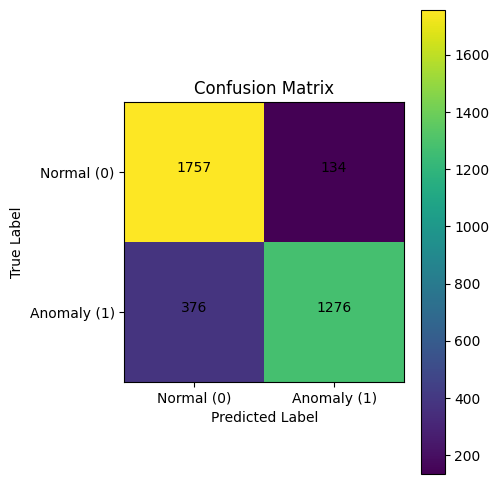

In [ ]:
# ============================================================
# AI Driven Log Anomaly Detection
# DeepLog++ (BiLSTM + Attention + Dynamic Threshold)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

from tensorflow.keras.layers import (
    Input, Embedding, LSTM, Dense,
    Bidirectional, Attention, GlobalAveragePooling1D
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow Version:", tf.__version__)

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------

# ------------------------------------------------------------
# LABEL MAPPING
# ------------------------------------------------------------

trace_df['Label'] = trace_df['Label'].map({'Success': 0, 'Fail': 1})

# ------------------------------------------------------------
# CONVERT FEATURES TO SEQUENCES
# ------------------------------------------------------------

trace_df['Features'] = trace_df['Features'].apply(
    lambda x: x.strip('[]').replace(" ", "").split(',')
)

all_events = set(e for seq in trace_df['Features'] for e in seq)
event_to_idx = {event: i+1 for i, event in enumerate(sorted(all_events))}
vocab_size = len(event_to_idx) + 1

trace_df['Features'] = trace_df['Features'].apply(
    lambda seq: [event_to_idx[e] for e in seq]
)

print("Vocabulary size:", vocab_size)

# ------------------------------------------------------------
# TRAIN / TEST SPLIT
# ------------------------------------------------------------

normal_df = trace_df[trace_df['Label'] == 0]
anomaly_df = trace_df[trace_df['Label'] == 1]

train_df, val_df = train_test_split(
    normal_df,
    test_size=0.1,
    random_state=42
)

test_df = pd.concat([val_df, anomaly_df])

print("Train blocks:", len(train_df))
print("Test blocks:", len(test_df))

# ------------------------------------------------------------
# SLIDING WINDOW
# ------------------------------------------------------------

window_size = 30   # Increased

def generate_sequences(df):
    X, y, block_ids = [], [], []
    
    for _, row in df.iterrows():
        seq = row['Features']
        block_id = row['BlockId']
        
        if len(seq) <= window_size:
            continue
        
        for i in range(len(seq) - window_size):
            X.append(seq[i:i+window_size])
            y.append(seq[i+window_size])
            block_ids.append(block_id)
    
    return np.array(X), np.array(y), np.array(block_ids)

X_train, y_train, _ = generate_sequences(train_df)
X_val, y_val, _ = generate_sequences(val_df)
X_test, y_test, test_block_ids = generate_sequences(test_df)

print("Train samples:", X_train.shape)
print("Validation samples:", X_val.shape)
print("Test samples:", X_test.shape)

# ------------------------------------------------------------
# BUILD MODEL (BiLSTM + Attention)
# ------------------------------------------------------------

inputs = Input(shape=(window_size,))

x = Embedding(vocab_size, 128, input_length=window_size)(inputs)

x = Bidirectional(LSTM(128, return_sequences=True))(x)

# Attention Layer
attention = Attention()([x, x])
x = GlobalAveragePooling1D()(attention)

outputs = Dense(vocab_size, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

# ------------------------------------------------------------
# TRAIN MODEL
# ------------------------------------------------------------

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=2048,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    shuffle=True
)

# ------------------------------------------------------------
# DYNAMIC THRESHOLD CALCULATION
# ------------------------------------------------------------

print("\nCalculating Dynamic Threshold...")

val_probs = model.predict(X_val, batch_size=2048)

true_probs_val = np.array([
    val_probs[i][y_val[i]] for i in range(len(y_val))
])

# Lower percentile = anomaly boundary
threshold = np.percentile(true_probs_val, 5)

print("Dynamic Threshold:", threshold)

# ------------------------------------------------------------
# TEST PREDICTION
# ------------------------------------------------------------

print("\nRunning Detection...\n")

test_probs = model.predict(X_test, batch_size=2048)

window_anomaly = []

for i in range(len(X_test)):
    true_prob = test_probs[i][y_test[i]]
    
    if true_prob < threshold:
        window_anomaly.append(1)
    else:
        window_anomaly.append(0)

window_anomaly = np.array(window_anomaly)

# ------------------------------------------------------------
# BLOCK LEVEL AGGREGATION
# ------------------------------------------------------------

block_pred = {}

for block_id, flag in zip(test_block_ids, window_anomaly):
    if block_id not in block_pred:
        block_pred[block_id] = 0
    if flag == 1:
        block_pred[block_id] = 1

true_labels = test_df.set_index('BlockId')['Label'].to_dict()

y_true = []
y_pred = []

for block_id in block_pred:
    y_true.append(true_labels[block_id])
    y_pred.append(block_pred[block_id])

# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

print("\n===== BLOCK LEVEL CLASSIFICATION REPORT =====\n")
print(classification_report(y_true, y_pred))

roc = roc_auc_score(y_true, y_pred)
print("ROC-AUC:", roc)

# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(y_true, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(5,5))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()

classes = ["Normal (0)", "Anomaly (1)"]
tick_marks = np.arange(len(classes))

plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center")

plt.tight_layout()
plt.show()

TensorFlow Version: 2.19.0
Vocabulary size: 30
Train blocks: 502400
Test blocks: 72661
Train samples: (46106, 30)
Validation samples: (6003, 30)
Test samples: (18673, 30)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 30, 128)   │      3,840 │ input_layer_4[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_4     │ (None, 30, 256)   │    263,168 │ embedding_4[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_4         │ (None, 30, 256)   │          0 │ bidirectional_4[… │
│ (Attention)         │                   │            │ bidirectional_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ attention_4[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 30)        │      7,710 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 274,718 (1.05 MB)

 Trainable params: 274,718 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.5613 - loss: 1.8772 - val_accuracy: 0.8049 - val_loss: 0.6556
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.8435 - loss: 0.5760 - val_accuracy: 0.8961 - val_loss: 0.3970
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.8965 - loss: 0.3788 - val_accuracy: 0.9069 - val_loss: 0.3253
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.9053 - loss: 0.3017 - val_accuracy: 0.9077 - val_loss: 0.2943
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.9066 - loss: 0.2734 - val_accuracy: 0.9140 - val_loss: 0.2697
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.9147 - loss: 0.2482 - val_accuracy: 0.9309 - val_loss: 0.2432
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.9215 - loss: 0.2288 - val_accuracy: 0.9289 - val_loss: 0.2237
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.9292 - loss: 0.2067 - val_accuracy: 0.9334 - val_loss:

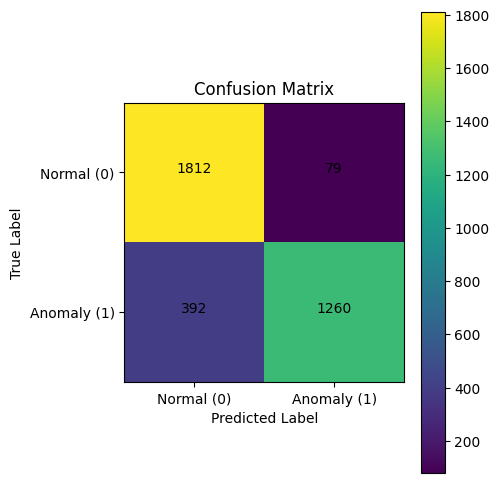

In [ ]:
# ============================================================
# AI Driven Log Anomaly Detection
# DeepLog++ FINAL (Stable Version)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

from tensorflow.keras.layers import (
    Input, Embedding, LSTM, Dense,
    Bidirectional, Attention, GlobalAveragePooling1D
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow Version:", tf.__version__)

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------

# ------------------------------------------------------------
# LABEL MAPPING
# ------------------------------------------------------------

trace_df['Label'] = trace_df['Label'].map({'Success': 0, 'Fail': 1})

# ------------------------------------------------------------
# CONVERT FEATURES TO SEQUENCES
# ------------------------------------------------------------

trace_df['Features'] = trace_df['Features'].apply(
    lambda x: x.strip('[]').replace(" ", "").split(',')
)

all_events = set(e for seq in trace_df['Features'] for e in seq)
event_to_idx = {event: i+1 for i, event in enumerate(sorted(all_events))}
vocab_size = len(event_to_idx) + 1

trace_df['Features'] = trace_df['Features'].apply(
    lambda seq: [event_to_idx[e] for e in seq]
)

print("Vocabulary size:", vocab_size)

# ------------------------------------------------------------
# TRAIN / TEST SPLIT
# ------------------------------------------------------------

normal_df = trace_df[trace_df['Label'] == 0]
anomaly_df = trace_df[trace_df['Label'] == 1]

train_df, val_df = train_test_split(
    normal_df,
    test_size=0.1,
    random_state=42
)

test_df = pd.concat([val_df, anomaly_df])

print("Train blocks:", len(train_df))
print("Test blocks:", len(test_df))

# ------------------------------------------------------------
# SLIDING WINDOW
# ------------------------------------------------------------

window_size = 30

def generate_sequences(df):
    X, y, block_ids = [], [], []
    
    for _, row in df.iterrows():
        seq = row['Features']
        block_id = row['BlockId']
        
        if len(seq) <= window_size:
            continue
        
        for i in range(len(seq) - window_size):
            X.append(seq[i:i+window_size])
            y.append(seq[i+window_size])
            block_ids.append(block_id)
    
    return np.array(X), np.array(y), np.array(block_ids)

X_train, y_train, _ = generate_sequences(train_df)
X_val, y_val, _ = generate_sequences(val_df)
X_test, y_test, test_block_ids = generate_sequences(test_df)

print("Train samples:", X_train.shape)
print("Validation samples:", X_val.shape)
print("Test samples:", X_test.shape)

# ------------------------------------------------------------
# BUILD MODEL (BiLSTM + Attention)
# ------------------------------------------------------------

inputs = Input(shape=(window_size,))

x = Embedding(vocab_size, 128, input_length=window_size)(inputs)

x = Bidirectional(LSTM(128, return_sequences=True, dropout=0.2))(x)

attention = Attention()([x, x])
x = GlobalAveragePooling1D()(attention)

outputs = Dense(vocab_size, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

# ------------------------------------------------------------
# TRAIN MODEL
# ------------------------------------------------------------

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=2048,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    shuffle=True
)

# ------------------------------------------------------------
# THRESHOLD (STATISTICAL METHOD - FIXED)
# ------------------------------------------------------------

print("\nCalculating Threshold...")

val_probs = model.predict(X_val, batch_size=2048, verbose=0)

true_probs_val = np.array([
    val_probs[i][y_val[i]] for i in range(len(y_val))
])

mean = np.mean(true_probs_val)
std = np.std(true_probs_val)

threshold = mean - 2 * std   # tune 1.5–2.5 if needed

print("Mean:", mean)
print("Std:", std)
print("Threshold:", threshold)

# ------------------------------------------------------------
# TEST PREDICTION
# ------------------------------------------------------------

print("\nRunning Detection...\n")

test_probs = model.predict(X_test, batch_size=2048, verbose=1)

window_anomaly = np.array([
    1 if test_probs[i][y_test[i]] < threshold else 0
    for i in range(len(X_test))
])

# ------------------------------------------------------------
# RATIO-BASED BLOCK AGGREGATION
# ------------------------------------------------------------

block_scores = {}

for block_id, flag in zip(test_block_ids, window_anomaly):
    if block_id not in block_scores:
        block_scores[block_id] = []
    block_scores[block_id].append(flag)

block_pred = {}

for block_id, flags in block_scores.items():
    anomaly_ratio = sum(flags) / len(flags)
    
    if anomaly_ratio > 0.2:   # tune 0.15–0.25
        block_pred[block_id] = 1
    else:
        block_pred[block_id] = 0

# ------------------------------------------------------------
# TRUE LABELS
# ------------------------------------------------------------

true_labels = test_df.set_index('BlockId')['Label'].to_dict()

y_true = []
y_pred = []

for block_id in block_pred:
    y_true.append(true_labels[block_id])
    y_pred.append(block_pred[block_id])

# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

print("\n===== BLOCK LEVEL CLASSIFICATION REPORT =====\n")
print(classification_report(y_true, y_pred))

roc = roc_auc_score(y_true, y_pred)
print("ROC-AUC:", roc)

# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(y_true, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(5,5))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()

classes = ["Normal (0)", "Anomaly (1)"]
tick_marks = np.arange(len(classes))

plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center")

plt.tight_layout()
plt.show()

TensorFlow Version: 2.19.0
Vocabulary size: 30
Train blocks: 502400
Test blocks: 72661
Train samples: (46106, 30)
Validation samples: (6003, 30)
Test samples: (18673, 30)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, 30, 128)   │      3,840 │ input_layer_5[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_5     │ (None, 30, 256)   │    263,168 │ embedding_5[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_5         │ (None, 30, 256)   │          0 │ bidirectional_5[… │
│ (Attention)         │                   │            │ bidirectional_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ attention_5[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 30)        │      7,710 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 274,718 (1.05 MB)

 Trainable params: 274,718 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.5583 - loss: 1.8154 - val_accuracy: 0.8737 - val_loss: 0.5532
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.8688 - loss: 0.5177 - val_accuracy: 0.8997 - val_loss: 0.3899
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.8967 - loss: 0.3719 - val_accuracy: 0.9064 - val_loss: 0.3255
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.9005 - loss: 0.3151 - val_accuracy: 0.9075 - val_loss: 0.2977
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.9038 - loss: 0.2816 - val_accuracy: 0.9080 - val_loss: 0.2791
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.9093 - loss: 0.2557 - val_accuracy: 0.9120 - val_loss: 0.2559
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.9149 - loss: 0.2334 - val_accuracy: 0.9245 - val_loss: 0.2378
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.9239 - loss: 0.2171 - val_accuracy: 0.9269 - val_loss:

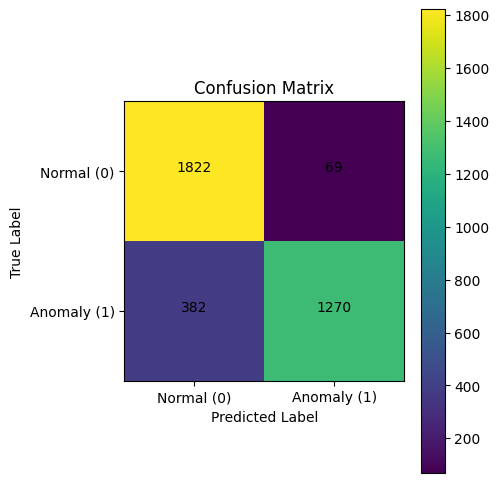

In [ ]:
# ============================================================
# AI Driven Log Anomaly Detection
# DeepLog++ FINAL (Stable Version)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

from tensorflow.keras.layers import (
    Input, Embedding, LSTM, Dense,
    Bidirectional, Attention, GlobalAveragePooling1D
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow Version:", tf.__version__)

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------

# ------------------------------------------------------------
# LABEL MAPPING
# ------------------------------------------------------------

trace_df['Label'] = trace_df['Label'].map({'Success': 0, 'Fail': 1})

# ------------------------------------------------------------
# CONVERT FEATURES TO SEQUENCES
# ------------------------------------------------------------

trace_df['Features'] = trace_df['Features'].apply(
    lambda x: x.strip('[]').replace(" ", "").split(',')
)

all_events = set(e for seq in trace_df['Features'] for e in seq)
event_to_idx = {event: i+1 for i, event in enumerate(sorted(all_events))}
vocab_size = len(event_to_idx) + 1

trace_df['Features'] = trace_df['Features'].apply(
    lambda seq: [event_to_idx[e] for e in seq]
)

print("Vocabulary size:", vocab_size)

# ------------------------------------------------------------
# TRAIN / TEST SPLIT
# ------------------------------------------------------------

normal_df = trace_df[trace_df['Label'] == 0]
anomaly_df = trace_df[trace_df['Label'] == 1]

train_df, val_df = train_test_split(
    normal_df,
    test_size=0.1,
    random_state=42
)

test_df = pd.concat([val_df, anomaly_df])

print("Train blocks:", len(train_df))
print("Test blocks:", len(test_df))

# ------------------------------------------------------------
# SLIDING WINDOW
# ------------------------------------------------------------

window_size = 30

def generate_sequences(df):
    X, y, block_ids = [], [], []
    
    for _, row in df.iterrows():
        seq = row['Features']
        block_id = row['BlockId']
        
        if len(seq) <= window_size:
            continue
        
        for i in range(len(seq) - window_size):
            X.append(seq[i:i+window_size])
            y.append(seq[i+window_size])
            block_ids.append(block_id)
    
    return np.array(X), np.array(y), np.array(block_ids)

X_train, y_train, _ = generate_sequences(train_df)
X_val, y_val, _ = generate_sequences(val_df)
X_test, y_test, test_block_ids = generate_sequences(test_df)

print("Train samples:", X_train.shape)
print("Validation samples:", X_val.shape)
print("Test samples:", X_test.shape)

# ------------------------------------------------------------
# BUILD MODEL (BiLSTM + Attention)
# ------------------------------------------------------------

inputs = Input(shape=(window_size,))

x = Embedding(vocab_size, 128, input_length=window_size)(inputs)

x = Bidirectional(LSTM(128, return_sequences=True, dropout=0.2))(x)

attention = Attention()([x, x])
x = GlobalAveragePooling1D()(attention)

outputs = Dense(vocab_size, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

# ------------------------------------------------------------
# TRAIN MODEL
# ------------------------------------------------------------

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=2048,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    shuffle=True
)

# ------------------------------------------------------------
# THRESHOLD (STATISTICAL METHOD - FIXED)
# ------------------------------------------------------------

print("\nCalculating Threshold...")

val_probs = model.predict(X_val, batch_size=2048, verbose=0)

true_probs_val = np.array([
    val_probs[i][y_val[i]] for i in range(len(y_val))
])

mean = np.mean(true_probs_val)
std = np.std(true_probs_val)

threshold = mean - 1.7 * std   # tune 1.5–2.5 if needed

print("Mean:", mean)
print("Std:", std)
print("Threshold:", threshold)

# ------------------------------------------------------------
# TEST PREDICTION
# ------------------------------------------------------------

print("\nRunning Detection...\n")

test_probs = model.predict(X_test, batch_size=2048, verbose=1)

window_anomaly = np.array([
    1 if test_probs[i][y_test[i]] < threshold else 0
    for i in range(len(X_test))
])

# ------------------------------------------------------------
# RATIO-BASED BLOCK AGGREGATION
# ------------------------------------------------------------

block_scores = {}

for block_id, flag in zip(test_block_ids, window_anomaly):
    if block_id not in block_scores:
        block_scores[block_id] = []
    block_scores[block_id].append(flag)

block_pred = {}

for block_id, flags in block_scores.items():
    anomaly_ratio = sum(flags) / len(flags)
    
    if anomaly_ratio > 0.15:   # tune 0.15–0.25
        block_pred[block_id] = 1
    else:
        block_pred[block_id] = 0

# ------------------------------------------------------------
# TRUE LABELS
# ------------------------------------------------------------

true_labels = test_df.set_index('BlockId')['Label'].to_dict()

y_true = []
y_pred = []

for block_id in block_pred:
    y_true.append(true_labels[block_id])
    y_pred.append(block_pred[block_id])

# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

print("\n===== BLOCK LEVEL CLASSIFICATION REPORT =====\n")
print(classification_report(y_true, y_pred))

roc = roc_auc_score(y_true, y_pred)
print("ROC-AUC:", roc)

# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(y_true, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(5,5))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()

classes = ["Normal (0)", "Anomaly (1)"]
tick_marks = np.arange(len(classes))

plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center")

plt.tight_layout()
plt.show()

TensorFlow Version: 2.19.0
Vocabulary size: 30


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_9         │ (None, 30, 128)   │      3,840 │ input_layer_9[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_8     │ (None, 30, 256)   │    263,168 │ embedding_9[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 256)   │    131,712 │ bidirectional_8[… │
│ (MultiHeadAttentio… │                   │            │ bidirectional_8[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 30, 256)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 30, 256)   │          0 │ bidirectional_8[… │
│                     │                   │            │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 256)   │        512 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 30, 128)   │     32,896 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 30, 256)   │     33,024 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 30, 256)   │          0 │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 30, 256)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 256)   │        512 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 30, 512)   │          0 │ bidirectional_8[… │
│ (Concatenate)       │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ concatenate_1[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 30)        │     15,390 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 481,054 (1.84 MB)

 Trainable params: 481,054 (1.84 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 141s 6s/step - accuracy: 0.5889 - loss: 1.3659 - val_accuracy: 0.8574 - val_loss: 0.5555
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 131s 6s/step - accuracy: 0.8668 - loss: 0.4920 - val_accuracy: 0.9095 - val_loss: 0.3287
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 131s 6s/step - accuracy: 0.9036 - loss: 0.3087 - val_accuracy: 0.9169 - val_loss: 0.2829
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 131s 6s/step - accuracy: 0.9156 - loss: 0.2602 - val_accuracy: 0.9227 - val_loss: 0.2508
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 131s 6s/step - accuracy: 0.9215 - loss: 0.2333 - val_accuracy: 0.9277 - val_loss: 0.2251
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 131s 6s/step - accuracy: 0.9296 - loss: 0.2074 - val_accuracy: 0.9449 - val_loss: 0.2032
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 135s 6s/step - accuracy: 0.9365 - loss: 0.1862 - val_accuracy: 0.9429 - val_loss: 0.1868
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 130s 6s/step - accuracy: 0.9451 - loss: 0.1607 - val_accuracy: 0.9494 - v

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


46/46 ━━━━━━━━━━━━━━━━━━━━ 44s 830ms/step - loss: 2.2976
Epoch 2/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 38s 823ms/step - loss: 1.0156
Epoch 3/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 38s 818ms/step - loss: 0.8348
Epoch 4/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 38s 823ms/step - loss: 0.7272
Epoch 5/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 40s 860ms/step - loss: 0.6866
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step
584/584 ━━━━━━━━━━━━━━━━━━━━ 18s 30ms/step

===== FINAL RESULTS =====

              precision    recall  f1-score   support

           0       0.62      1.00      0.76      1891
           1       1.00      0.28      0.44      1652

    accuracy                           0.67      3543
   macro avg       0.81      0.64      0.60      3543
weighted avg       0.79      0.67      0.61      3543

ROC-AUC: 0.6422518159806295

Confusion Matrix:
 [[1891    0]
 [1182  470]]


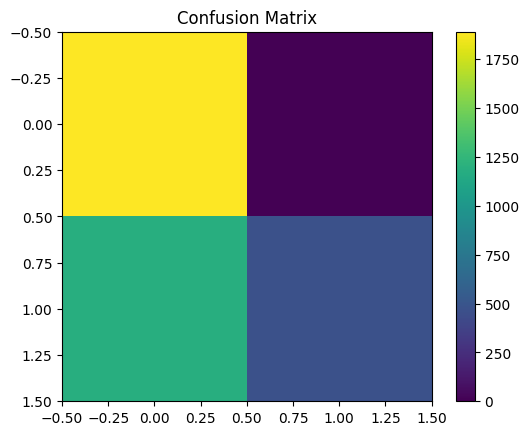

In [ ]:
# ============================================================
# SOTA Log Anomaly Detection (FINAL - FULLY FIXED)
# DeepLog + Transformer + Autoencoder (Hybrid)
# ============================================================

import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

from tensorflow.keras.layers import (
    Input, Embedding, LSTM, Dense, Bidirectional,
    GlobalAveragePooling1D, MultiHeadAttention,
    LayerNormalization, Dropout, RepeatVector,
    TimeDistributed, Concatenate
)
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow Version:", tf.__version__)

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------

trace_df['Label'] = trace_df['Label'].map({'Success': 0, 'Fail': 1})

# ------------------------------------------------------------
# PREPROCESS
# ------------------------------------------------------------

trace_df['Features'] = trace_df['Features'].apply(
    lambda x: x.strip('[]').replace(" ", "").split(',')
)

all_events = set(e for seq in trace_df['Features'] for e in seq)
event_to_idx = {event: i+1 for i, event in enumerate(sorted(all_events))}
vocab_size = len(event_to_idx) + 1

trace_df['Features'] = trace_df['Features'].apply(
    lambda seq: [event_to_idx[e] for e in seq]
)

print("Vocabulary size:", vocab_size)

# ------------------------------------------------------------
# SPLIT
# ------------------------------------------------------------

normal_df = trace_df[trace_df['Label'] == 0]
anomaly_df = trace_df[trace_df['Label'] == 1]

train_df, val_df = train_test_split(normal_df, test_size=0.1, random_state=42)
test_df = pd.concat([val_df, anomaly_df])

# ------------------------------------------------------------
# SLIDING WINDOW
# ------------------------------------------------------------

window_size = 30

def generate_sequences(df):
    X, y, block_ids = [], [], []
    
    for _, row in df.iterrows():
        seq = row['Features']
        block_id = row['BlockId']
        
        if len(seq) <= window_size:
            continue
        
        for i in range(len(seq) - window_size):
            X.append(seq[i:i+window_size])
            y.append(seq[i+window_size])
            block_ids.append(block_id)
    
    return np.array(X), np.array(y), np.array(block_ids)

X_train, y_train, _ = generate_sequences(train_df)
X_val, y_val, _ = generate_sequences(val_df)
X_test, y_test, test_block_ids = generate_sequences(test_df)

# ------------------------------------------------------------
# TRANSFORMER BLOCK
# ------------------------------------------------------------

def transformer_block(x, head_size=64, num_heads=2, ff_dim=128):
    attn = MultiHeadAttention(num_heads=num_heads, key_dim=head_size)(x, x)
    attn = Dropout(0.1)(attn)
    x = LayerNormalization(epsilon=1e-6)(x + attn)

    ffn = Dense(ff_dim, activation="relu")(x)
    ffn = Dense(x.shape[-1])(ffn)
    ffn = Dropout(0.1)(ffn)

    return LayerNormalization(epsilon=1e-6)(x + ffn)

# ------------------------------------------------------------
# HYBRID MODEL (BiLSTM + Transformer)
# ------------------------------------------------------------

inputs = Input(shape=(window_size,))
x = Embedding(vocab_size, 128)(inputs)

lstm_out = Bidirectional(LSTM(128, return_sequences=True, dropout=0.2))(x)

trans_out = transformer_block(lstm_out)

merged = Concatenate(axis=-1)([lstm_out, trans_out])

x = GlobalAveragePooling1D()(merged)

outputs = Dense(vocab_size, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

# ------------------------------------------------------------
# TRAIN MAIN MODEL
# ------------------------------------------------------------

early_stop = EarlyStopping(patience=2, restore_best_weights=True)

model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=2048,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

# ------------------------------------------------------------
# AUTOENCODER MODEL
# ------------------------------------------------------------

ae = Sequential([
    Embedding(vocab_size, 64, input_length=window_size),
    LSTM(128),
    RepeatVector(window_size),
    LSTM(128, return_sequences=True),
    TimeDistributed(Dense(vocab_size, activation='softmax'))
])

ae.compile(loss='sparse_categorical_crossentropy', optimizer='adam')

ae.fit(
    X_train,
    np.expand_dims(X_train, -1),
    epochs=5,
    batch_size=1024
)

# ------------------------------------------------------------
# PREDICTION SCORES
# ------------------------------------------------------------

test_probs = model.predict(X_test, batch_size=2048)

true_probs = np.array([
    test_probs[i][y_test[i]] for i in range(len(y_test))
])

pred_score = 1 - true_probs

# ------------------------------------------------------------
# AUTOENCODER RECONSTRUCTION ERROR (FIXED)
# ------------------------------------------------------------

recon = ae.predict(X_test)

recon_error = np.array([
    1 - np.mean([recon[i][t][X_test[i][t]] for t in range(window_size)])
    for i in range(len(X_test))
])

# ------------------------------------------------------------
# HYBRID SCORE
# ------------------------------------------------------------

alpha = 0.7
beta = 0.3

final_score = alpha * pred_score + beta * recon_error

# ------------------------------------------------------------
# THRESHOLD
# ------------------------------------------------------------

threshold = np.percentile(final_score, 90)

window_anomaly = (final_score > threshold).astype(int)

# ------------------------------------------------------------
# BLOCK AGGREGATION
# ------------------------------------------------------------

block_scores = {}

for block_id, flag in zip(test_block_ids, window_anomaly):
    if block_id not in block_scores:
        block_scores[block_id] = []
    block_scores[block_id].append(flag)

block_pred = {}

for block_id, flags in block_scores.items():
    ratio = sum(flags) / len(flags)
    
    if ratio > 0.2:
        block_pred[block_id] = 1
    else:
        block_pred[block_id] = 0

# ------------------------------------------------------------
# EVALUATION
# ------------------------------------------------------------

true_labels = test_df.set_index('BlockId')['Label'].to_dict()

y_true = []
y_pred = []

for block_id in block_pred:
    y_true.append(true_labels[block_id])
    y_pred.append(block_pred[block_id])

print("\n===== FINAL RESULTS =====\n")
print(classification_report(y_true, y_pred))

roc = roc_auc_score(y_true, y_pred)
print("ROC-AUC:", roc)

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:\n", cm)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()